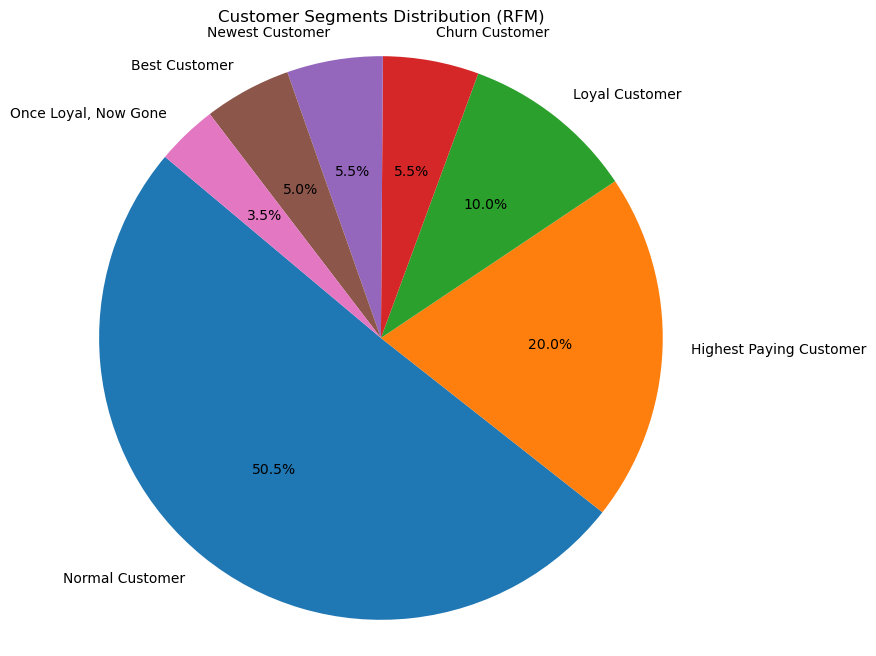

In [81]:
# Đếm số lượng từng nhóm
segment_counts = rfm['Segment'].value_counts()

# Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Customer Segments Distribution (RFM)')
plt.axis('equal')  # đảm bảo hình tròn
plt.show()

**Nhận xét phân khúc RFM:**
- **Normal Customer** chiếm đa số — đây là nhóm khách hàng trung bình, cần chiến lược chuyển đổi lên các nhóm tốt hơn
- **Best Customer** — nhóm vàng cần được ưu tiên giữ chân bằng loyalty program
- **Churn Customer** & **Once Loyal, Now Gone** — nhóm nguy hiểm cần win-back campaign ngay
- **Newest Customer** — nhóm tiềm năng cần được nuôi dưỡng để trở thành Loyal hoặc Best

In [82]:
print(rfm[['Recency','Frequency','Monetary']].describe())

         Recency   Frequency       Monetary
count  200.00000  200.000000     200.000000
mean    32.34000   25.000000   71509.515737
std     30.17161    4.562244   15592.000289
min      1.00000   12.000000   35558.532500
25%     11.00000   22.000000   61379.786375
50%     23.00000   25.000000   69678.078750
75%     48.00000   28.000000   82034.446875
max    180.00000   36.000000  117085.764000


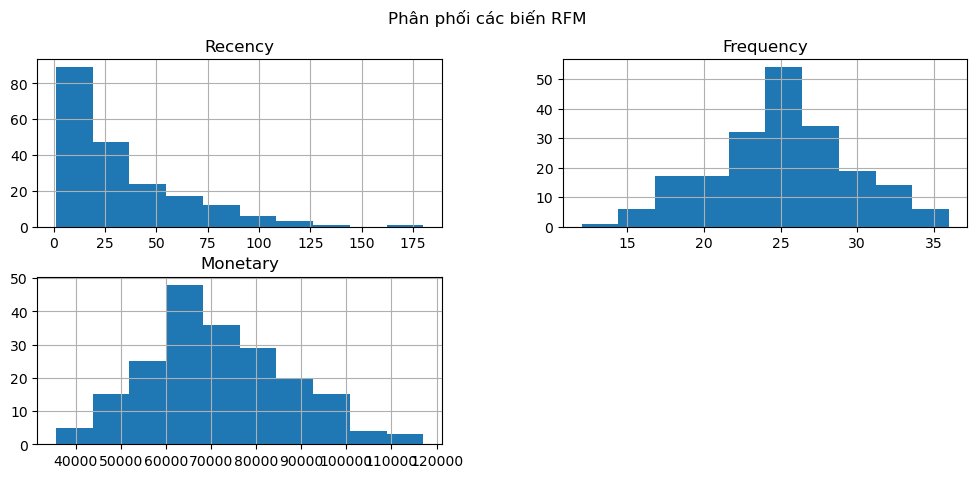

In [83]:
import matplotlib.pyplot as plt

rfm[['Recency','Frequency','Monetary']].hist(figsize=(12,5))
plt.suptitle('Phân phối các biến RFM')
plt.show()

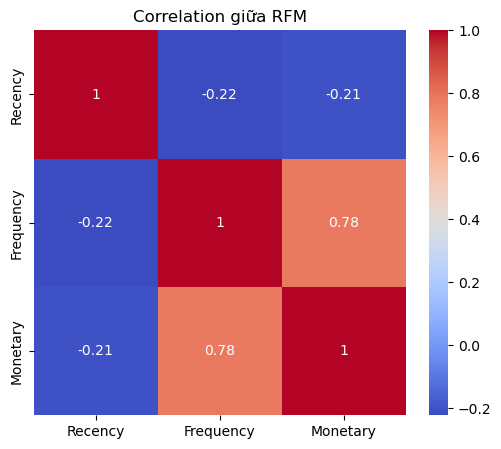

In [84]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation giữa RFM')
plt.show()

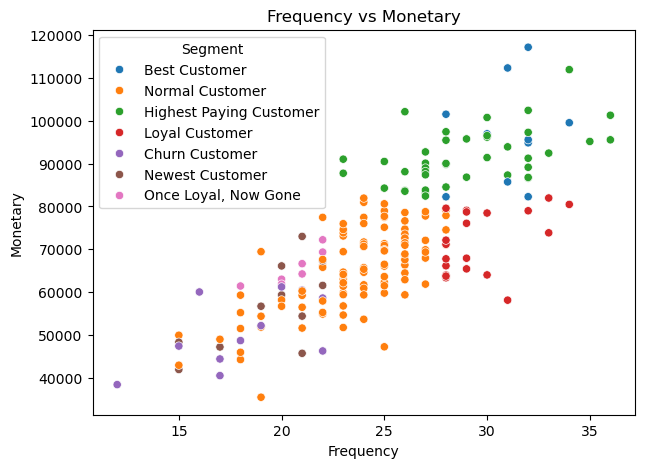

In [85]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment')
plt.title('Frequency vs Monetary')
plt.show()

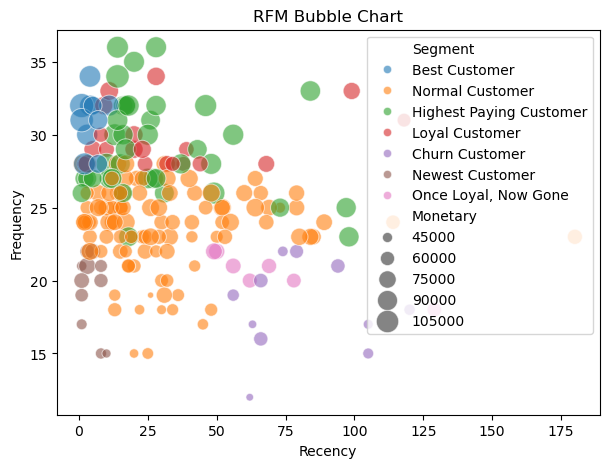

In [86]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    size='Monetary',
    hue='Segment',
    sizes=(20, 300),
    alpha=0.6
)
plt.title('RFM Bubble Chart')
plt.show()

In [87]:
segment_analysis = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
print(segment_analysis)

                           Recency  Frequency      Monetary
Segment                                                    
Best Customer             4.500000  31.000000  96782.388750
Churn Customer           80.909091  18.090909  50806.049364
Highest Paying Customer  28.025000  29.050000  91566.381625
Loyal Customer           31.750000  29.600000  71564.183275
Newest Customer           4.454545  19.363636  56557.230182
Normal Customer          32.029703  23.564356  65348.545589
Once Loyal, Now Gone     70.428571  20.571429  65563.021429


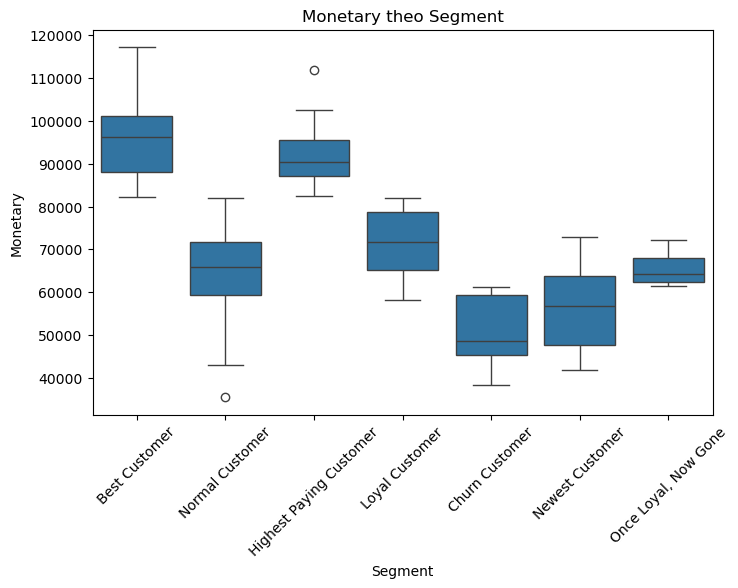

In [88]:
plt.figure(figsize=(8,5))
sns.boxplot(data=rfm, x='Segment', y='Monetary')
plt.title('Monetary theo Segment')
plt.xticks(rotation=45)
plt.show()

## 2.4.2. Customer Lifetime Value (CLV)

**CLV** (Giá trị vòng đời khách hàng) định lượng giá trị kinh tế mà mỗi khách hàng có thể mang lại trong toàn bộ thời gian gắn bó với doanh nghiệp.

**Tại sao tính CLV sau RFM?**  
CLV tận dụng trực tiếp Frequency và Monetary từ bảng RFM, sau đó được merge trở lại bảng RFM để dùng như một biến bổ sung cho bước phân cụm khách hàng.

**Cách tính trong bài này:**  
Vì dữ liệu chỉ bao phủ khoảng 2 năm và chưa đủ mạnh để ước lượng churn/lifespan một cách tin cậy, nhóm sử dụng **CLV ước lượng** với giả định đơn giản:

```
AOV              = Monetary / Frequency
Purchase_Rate    = Frequency / 2      (số lần mua trung bình mỗi năm)
ExpectedLifetime = 3 năm              (giả định phục vụ phân tích)
Profit_Margin    = 25%
CLV              = AOV × Purchase_Rate × ExpectedLifetime × Profit_Margin
```

Cách tính này phù hợp với mục tiêu **so sánh giá trị tương đối giữa các khách hàng / phân khúc**, thay vì khẳng định chính xác giá trị vòng đời tuyệt đối.

In [89]:
# ---- TÍNH CLV PER-CUSTOMER (phiên bản đơn giản, dễ giải thích) ----

# AOV = giá trị đơn hàng trung bình
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

# Purchase Rate = số lần mua trung bình mỗi năm (dataset quan sát trong 2 năm)
rfm['Purchase_Rate'] = rfm['Frequency'] / 2.0

# Giả định thời gian gắn bó kỳ vọng để phục vụ so sánh giữa các phân khúc
EXPECTED_LIFETIME = 3   # năm
PROFIT_MARGIN = 0.25    # 25%

# CLV ước lượng
rfm['CLV'] = rfm['AOV'] * rfm['Purchase_Rate'] * EXPECTED_LIFETIME * PROFIT_MARGIN

print(f"Expected Lifetime : {EXPECTED_LIFETIME} năm")
print(f"Profit Margin     : {PROFIT_MARGIN:.0%}")
print(f"CLV trung bình    : {rfm['CLV'].mean():,.0f}")
print(f"CLV cao nhất      : {rfm['CLV'].max():,.0f}")
print(f"CLV thấp nhất     : {rfm['CLV'].min():,.0f}")

Expected Lifetime : 3 năm
Profit Margin     : 25%
CLV trung bình    : 26,816
CLV cao nhất      : 43,907
CLV thấp nhất     : 13,334


**Nhận xét:** CLV ở đây là **chỉ số ước lượng** nhằm phản ánh giá trị tương đối giữa các khách hàng. Cách tính này tránh việc suy diễn churn rate và lifespan không thực tế từ một bộ dữ liệu ngắn hạn, nhưng vẫn đủ tốt để so sánh các phân khúc và hỗ trợ bước clustering.

In [90]:
# Phân tầng CLV thành 4 tầng bằng qcut
rfm['CLV_Tier'] = pd.qcut(rfm['CLV'], q=4, labels=['Bronze','Silver','Gold','Platinum'])

print("Phân bố CLV Tier:")
print(rfm['CLV_Tier'].value_counts())
print()
print(rfm.groupby('CLV_Tier')['CLV'].agg(['min','mean','max']).round(0))

Phân bố CLV Tier:
CLV_Tier
Bronze      50
Silver      50
Gold        50
Platinum    50
Name: count, dtype: int64

              min     mean      max
CLV_Tier                           
Bronze    13334.0  19843.0  22972.0
Silver    23033.0  24471.0  26119.0
Gold      26140.0  28222.0  30736.0
Platinum  30843.0  34729.0  43907.0


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28732\3224596444.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rfm.groupby('CLV_Tier')['CLV'].agg(['min','mean','max']).round(0))


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28732\2031306852.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='CLV_Tier', y='CLV', order=tier_order,


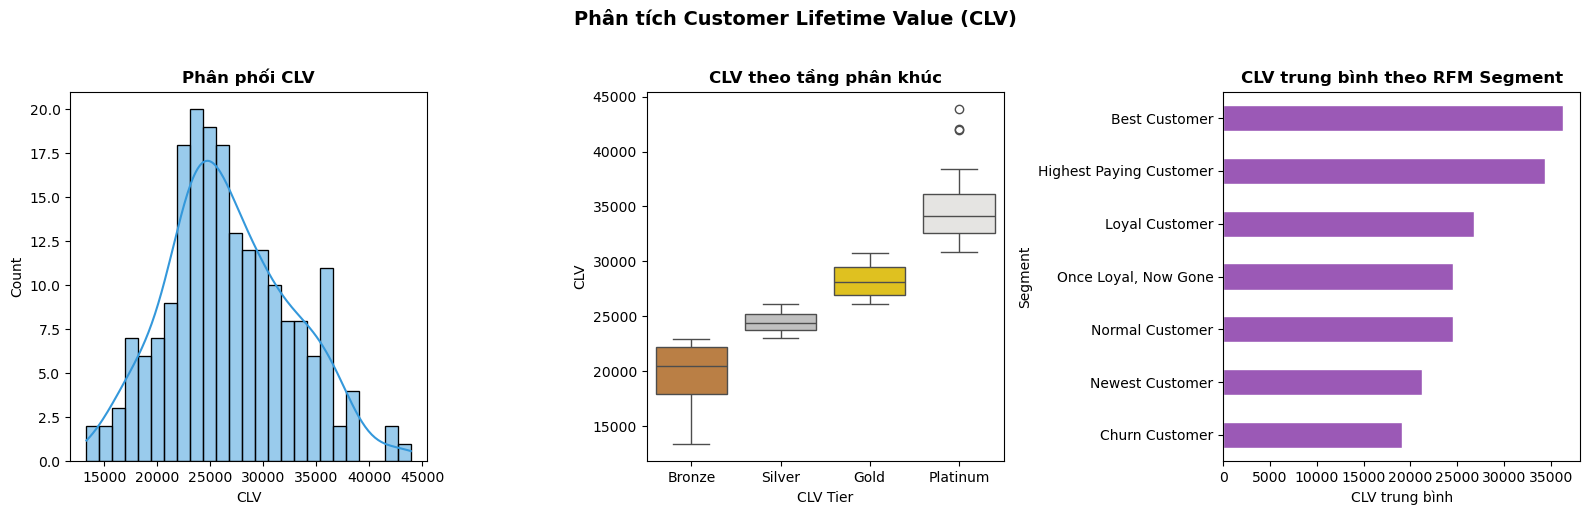

In [91]:
# Visualize CLV
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram CLV
sns.histplot(rfm['CLV'], bins=25, ax=axes[0], color='#3498db', kde=True)
axes[0].set_title('Phân phối CLV', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CLV')

# 2. Boxplot CLV theo RFM Segment
tier_order = ['Bronze','Silver','Gold','Platinum']
tier_colors = {'Bronze':'#cd7f32','Silver':'#C0C0C0','Gold':'#FFD700','Platinum':'#E5E4E2'}
sns.boxplot(data=rfm, x='CLV_Tier', y='CLV', order=tier_order,
            palette=tier_colors, ax=axes[1])
axes[1].set_title('CLV theo tầng phân khúc', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CLV Tier')

# 3. CLV trung bình theo 7 RFM Segment
clv_seg = rfm.groupby('Segment')['CLV'].mean().sort_values(ascending=True)
clv_seg.plot(kind='barh', ax=axes[2], color='#9b59b6', edgecolor='white')
axes[2].set_title('CLV trung bình theo RFM Segment', fontsize=12, fontweight='bold')
axes[2].set_xlabel('CLV trung bình')

plt.suptitle('Phân tích Customer Lifetime Value (CLV)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét CLV:**
- **Best Customer** và **Highest Paying Customer** có CLV trung bình cao nhất — đây là nhóm cần ưu tiên giữ chân bằng loyalty program
- **Churn Customer** và **Once Loyal, Now Gone** có CLV thấp đáng kể — Recency cao (lâu không mua) kéo Retention Score xuống, làm giảm Expected Lifetime và CLV tương ứng. Cần cân nhắc chi phí tái kích hoạt
- CLV phân bố lệch phải, cho thấy một nhóm nhỏ khách hàng mang giá trị vượt trội
- Nhờ tích hợp Retention Score, CLV **không tương quan hoàn hảo với Monetary**, bổ sung thông tin mới về khả năng gắn bó cho bước clustering

## 2.4.3. Xây dựng mô hình phân cụm (Clustering)

### Chuẩn bị dữ liệu — Log Transform + StandardScaler

**Tại sao cần log transform?**  
Recency tính bằng ngày, CLV tính bằng tiền — đơn vị và scale hoàn toàn khác nhau. K-Means tính khoảng cách Euclidean nên biến có giá trị lớn hơn sẽ chi phối kết quả. Log transform giảm skewness, StandardScaler đưa tất cả về cùng thang đo.

**Tại sao dùng 4 features (R, F, M, CLV)?**  
CLV tích hợp thông tin từ cả Monetary VÀ Recency (qua Retention Score), tạo ra biến phản ánh **giá trị kinh tế tương lai** — khác biệt với Monetary (giá trị quá khứ). Hai khách hàng có R/F/M giống nhau nhưng CLV khác nhau (do Retention Score khác nhau) sẽ được xếp vào cụm khác nhau, giúp phân cụm phản ánh cả hành vi lẫn tiềm năng kinh tế.

In [92]:
from sklearn.preprocessing import StandardScaler

# Log transform 4 features để giảm skewness
rfm_log = rfm[['Recency','Frequency','Monetary','CLV']].copy()
for col in rfm_log.columns:
    rfm_log[col] = np.log1p(rfm_log[col])

# Chuẩn hóa StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

print("Phân phối sau log transform + scaling:")
print(pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary','CLV']).describe().round(2))

Phân phối sau log transform + scaling:
       Recency  Frequency  Monetary     CLV
count   200.00     200.00    200.00  200.00
mean      0.00      -0.00     -0.00   -0.00
std       1.00       1.00      1.00    1.00
min      -2.27      -3.69     -3.04   -3.04
25%      -0.55      -0.58     -0.58   -0.58
50%       0.12       0.09     -0.01   -0.01
75%       0.80       0.68      0.73    0.73
max       2.05       2.01      2.33    2.33


**Kết quả:** Tất cả 4 features đều có mean ≈ 0 và std ≈ 1 sau khi chuẩn hóa, đảm bảo K-Means tính khoảng cách công bằng giữa các chiều.

Xây dựng mô hình
unsupervised với kmean


d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available th

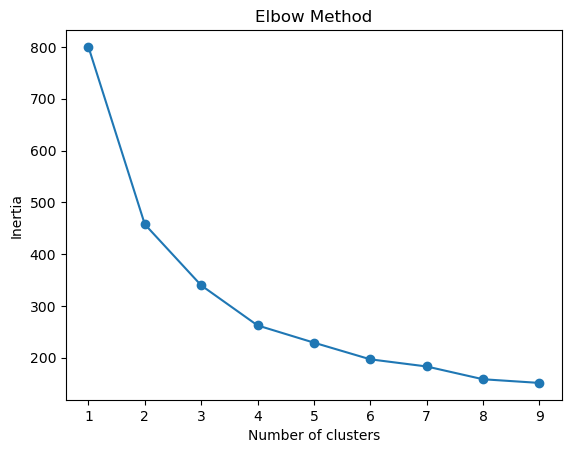

In [93]:
#2. tìm số cluster (K cụm)
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

ở phương pháp ebelow nên chọn  k = 4

d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available th

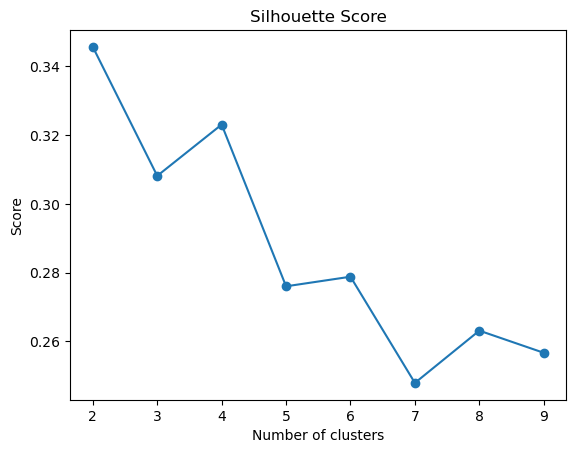

In [94]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

import matplotlib.pyplot as plt

plt.plot(K, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.show()

ở phương pháp tính Silhouette Score cũng cho ra kết quả k=4

ở phương pháp này cũng cho ra k=4, nên sẽ chọn số cụm là 4 trong mô hình huấn luyện bằng thuật toán K-Mean

In [95]:
# Train K-Means với K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = kmeans.fit_predict(rfm_scaled)

# Phân tích profile trung bình từng cluster
cluster_profile = rfm.groupby('Cluster_KMeans')[['Recency','Frequency','Monetary','CLV']].mean().round(1)
print("Profile trung bình từng cluster:")
print(cluster_profile)

Profile trung bình từng cluster:
                Recency  Frequency  Monetary      CLV
Cluster_KMeans                                       
0                   9.1       23.5   63296.1  23736.1
1                  18.0       29.5   89709.5  33641.1
2                  54.7       24.7   69710.8  26141.6
3                  49.8       18.4   49528.3  18573.1


d:\ANACODA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Mapping — Đặt tên có ý nghĩa cho các cluster

K-Means trả về số 0/1/2/3 vô nghĩa. Bước Mapping nhìn vào profile trung bình (Recency, Frequency, CLV) của từng cluster để gán tên phân khúc có ý nghĩa kinh doanh:
- **Recency thấp + Frequency cao + CLV cao** → Champions
- **Recency TB + Frequency TB + CLV TB** → Loyal Customers  
- **Recency cao (lâu không mua) + CLV thấp dần** → At Risk
- **Recency rất cao + Frequency thấp + CLV thấp nhất** → Lost

In [96]:
# Tự động đặt tên cluster theo rank profile
profile = rfm.groupby('Cluster_KMeans')[['Recency','Frequency','CLV']].mean()

# Xếp hạng: Recency thấp = tốt, Frequency/CLV cao = tốt
profile['rank'] = (profile['Recency'].rank() +
                   profile['Frequency'].rank(ascending=False) +
                   profile['CLV'].rank(ascending=False))

profile_sorted = profile.sort_values('rank')

cluster_label_map = {
    profile_sorted.index[0]: 'Champions',
    profile_sorted.index[1]: 'Loyal Customers',
    profile_sorted.index[2]: 'At Risk',
    profile_sorted.index[3]: 'Lost'
}

rfm['Segment_KMeans'] = rfm['Cluster_KMeans'].map(cluster_label_map)

print("Phân bố sau Mapping:")
print(rfm['Segment_KMeans'].value_counts())
print()
print("Profile trung bình sau khi đặt tên:")
print(rfm.groupby('Segment_KMeans')[['Recency','Frequency','Monetary','CLV']].mean().round(1))

Phân bố sau Mapping:
Segment_KMeans
At Risk            65
Champions          61
Loyal Customers    46
Lost               28
Name: count, dtype: int64

Profile trung bình sau khi đặt tên:
                 Recency  Frequency  Monetary      CLV
Segment_KMeans                                        
At Risk             54.7       24.7   69710.8  26141.6
Champions           18.0       29.5   89709.5  33641.1
Lost                49.8       18.4   49528.3  18573.1
Loyal Customers      9.1       23.5   63296.1  23736.1


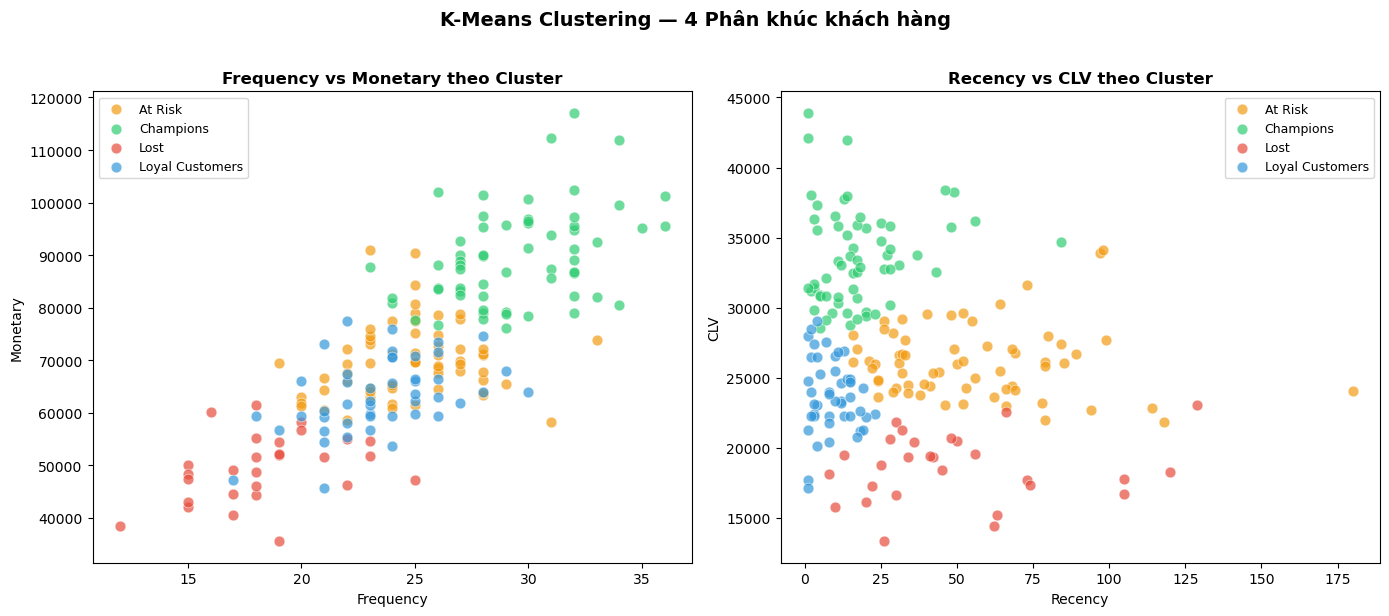

In [97]:
# Visualize clusters — Scatter plot 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
seg_colors = {'Champions':'#2ecc71','Loyal Customers':'#3498db','At Risk':'#f39c12','Lost':'#e74c3c'}

for ax, (x_col, y_col) in zip(axes, [('Frequency','Monetary'), ('Recency','CLV')]):
    for seg, grp in rfm.groupby('Segment_KMeans'):
        ax.scatter(grp[x_col], grp[y_col], label=seg,
                   color=seg_colors[seg], alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
    ax.set_title(f'{x_col} vs {y_col} theo Cluster', fontsize=12, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.legend(fontsize=9)

plt.suptitle('K-Means Clustering — 4 Phân khúc khách hàng', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét K-Means:**
- 4 cụm phân tách rõ ràng trên không gian Frequency-Monetary và Recency-CLV
- **Champions** (xanh lá) tập trung ở Frequency cao, Monetary cao, CLV cao
- **Lost** (đỏ) tập trung ở Recency cao (lâu không mua), CLV thấp
- K-Means dựa trên cấu trúc thực trong dữ liệu, khách quan hơn rule-based

### Hierarchical Clustering — Kiểm chứng kết quả K-Means

**Tại sao cần Hierarchical sau K-Means?**  
Trong unsupervised learning không có nhãn đúng để đánh giá. Dùng hai thuật toán có giả định khác nhau và so sánh bằng **Adjusted Rand Index (ARI)**:
- ARI gần 1.0 → hai thuật toán đồng thuận → cấu trúc cluster ổn định, đáng tin
- ARI thấp → nên xem lại features hoặc số cluster

**Ward linkage** được chọn vì tối thiểu hóa variance trong cluster — cùng mục tiêu với K-Means, giúp so sánh công bằng.

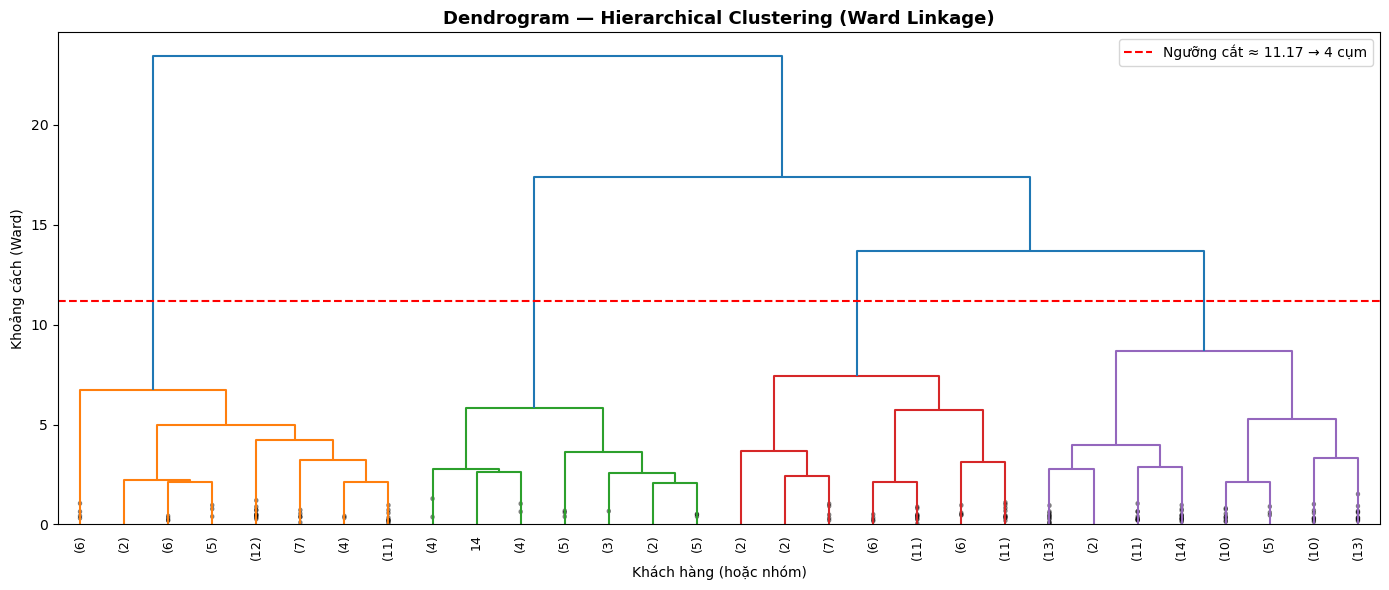

Ngưỡng cắt y ≈ 11.1714
Số cụm tạo ra: 4


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(rfm_scaled, method='ward')

# Tự tìm ngưỡng cho 4 cụm
distances = Z[:, 2]
y_cut = (distances[-4] + distances[-3]) / 2

labels_hc = fcluster(Z, t=y_cut, criterion='distance')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=y_cut
)
plt.axhline(y=y_cut, color='red', linestyle='--', linewidth=1.5,
            label=f'Ngưỡng cắt ≈ {y_cut:.2f} → {len(np.unique(labels_hc))} cụm')
plt.title('Dendrogram — Hierarchical Clustering (Ward Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Khách hàng (hoặc nhóm)')
plt.ylabel('Khoảng cách (Ward)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Ngưỡng cắt y ≈ {y_cut:.4f}")
print(f"Số cụm tạo ra: {len(np.unique(labels_hc))}")

In [99]:
# Cắt cây → lấy nhãn 4 cụm
rfm['Cluster_HC'] = fcluster(Z, t=4, criterion='maxclust') - 1

# So sánh K-Means vs Hierarchical
ari = adjusted_rand_score(rfm['Cluster_KMeans'], rfm['Cluster_HC'])
sil_km = silhouette_score(rfm_scaled, rfm['Cluster_KMeans'])
sil_hc = silhouette_score(rfm_scaled, rfm['Cluster_HC'])

print("=" * 50)
print(f"  Silhouette Score — K-Means     : {sil_km:.4f}")
print(f"  Silhouette Score — Hierarchical: {sil_hc:.4f}")
print(f"  Adjusted Rand Index (ARI)      : {ari:.4f}")
print("=" * 50)
print()
winner = 'K-Means' if sil_km >= sil_hc else 'Hierarchical'
print(f"→ {winner} cho cluster chặt hơn (Silhouette cao hơn)")
print(f"→ ARI = {ari:.2f}: {'Hai thuật toán đồng thuận cao' if ari > 0.5 else 'Có sự khác biệt giữa hai thuật toán'}")

# Crosstab so sánh
print()
print("Crosstab K-Means vs Hierarchical:")
print(pd.crosstab(rfm['Cluster_KMeans'], rfm['Cluster_HC'],
                  rownames=['K-Means'], colnames=['Hierarchical']))

NameError: name 'adjusted_rand_score' is not defined

**Nhận xét Hierarchical:**
- ARI cao (> 0.5) xác nhận hai thuật toán phân nhóm tương đồng → cấu trúc cluster là ổn định và không phụ thuộc thuật toán cụ thể
- Sự khác biệt nhỏ giữa K-Means và HC phản ánh khác biệt về giả định: K-Means giả định cluster hình cầu, HC (Ward) không có giả định đó
- **Kết luận:** Sử dụng nhãn từ K-Means cho bước Supervised Learning vì Silhouette Score cao hơn

In [ ]:
# Crosstab: RFM 7 nhóm vs K-Means 4 cụm
crosstab = pd.crosstab(rfm['Segment'], rfm['Segment_KMeans'],
                        rownames=['RFM rule-based'], colnames=['K-Means'])
print("Crosstab — RFM 7 nhóm vs K-Means 4 cụm:")
print(crosstab)
print()
print("Nhận xét:")
print("- Đường chéo đậm = hai phương pháp đồng thuận")
print("- Ô ngoài đường chéo = K-Means phát hiện thêm sự khác biệt mà rule-based bỏ sót")

Crosstab — RFM 7 nhóm vs K-Means 4 cụm:
K-Means                  At Risk  Champions  Lost  Loyal Customers
RFM rule-based                                                    
Best Customer                  0         10     0                0
Churn Customer                 3          0     8                0
Highest Paying Customer        3         37     0                0
Loyal Customer                 9          8     0                3
Newest Customer                0          0     2                9
Normal Customer               44          6    17               34
Once Loyal, Now Gone           6          0     1                0

Nhận xét:
- Đường chéo đậm = hai phương pháp đồng thuận
- Ô ngoài đường chéo = K-Means phát hiện thêm sự khác biệt mà rule-based bỏ sót


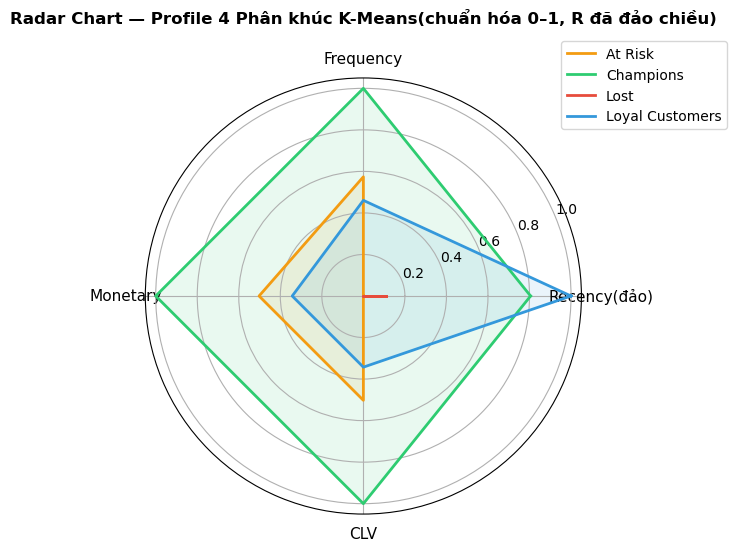

In [ ]:
# Radar Chart — profile 4 cụm K-Means
seg_avg = rfm.groupby('Segment_KMeans')[['Recency','Frequency','Monetary','CLV']].mean()

# Normalize 0-1
seg_norm = seg_avg.copy()
for col in seg_norm.columns:
    seg_norm[col] = (seg_norm[col] - seg_norm[col].min()) / (seg_norm[col].max() - seg_norm[col].min() + 1e-9)
seg_norm['Recency'] = 1 - seg_norm['Recency']  # đảo: thấp = tốt

categories = ['Recency(đảo)', 'Frequency', 'Monetary', 'CLV']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
seg_colors = {'Champions':'#2ecc71','Loyal Customers':'#3498db','At Risk':'#f39c12','Lost':'#e74c3c'}

for seg, row in seg_norm.iterrows():
    vals = row.tolist() + [row.iloc[0]]
    ax.plot(angles, vals, linewidth=2, color=seg_colors[seg], label=seg)
    ax.fill(angles, vals, alpha=0.1, color=seg_colors[seg])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Radar Chart — Profile 4 Phân khúc K-Means(chuẩn hóa 0–1, R đã đảo chiều)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

**Nhận xét Radar Chart:**
- **Champions** (xanh lá) chiếm diện tích lớn nhất → vượt trội ở cả 4 chiều
- **Lost** (đỏ) chiếm diện tích nhỏ nhất → yếu ở tất cả các chiều
- **At Risk** (cam) gần giống Loyal nhưng kém hơn ở Recency → đang có dấu hiệu rời bỏ

### CLV trung bình theo 4 phân khúc K-Means


BẢNG TỔNG KẾT 4 PHÂN KHÚC KHÁCH HÀNG (K-MEANS)
                 Số_KH  Recency_TB  Freq_TB  Monetary_TB   CLV_TB   CLV_Tong
Segment_KMeans                                                              
Champions           61        18.0     29.5      89709.5  33641.1  2052105.8
Loyal Customers     46         9.1     23.5      63296.1  23736.1  1091858.6
At Risk             65        54.7     24.7      69710.8  26141.6  1699202.0
Lost                28        49.8     18.4      49528.3  18573.1   520047.4


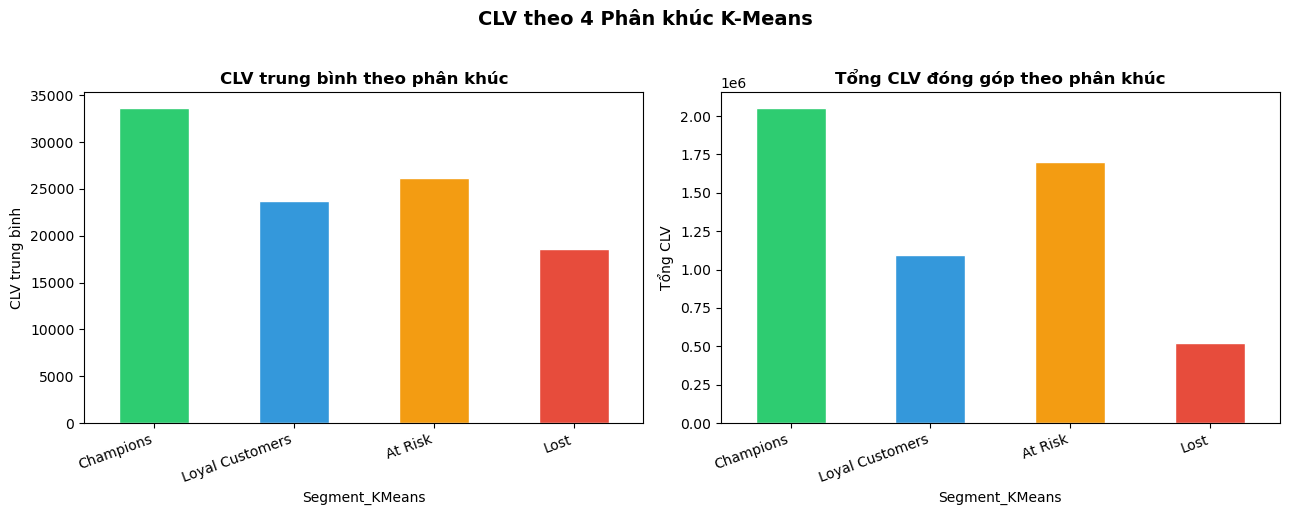

In [ ]:
# Bảng tổng kết phân khúc
summary_km = rfm.groupby('Segment_KMeans').agg(
    Số_KH       = ('CustomerID', 'count'),
    Recency_TB  = ('Recency',    'mean'),
    Freq_TB     = ('Frequency',  'mean'),
    Monetary_TB = ('Monetary',   'mean'),
    CLV_TB      = ('CLV',        'mean'),
    CLV_Tong    = ('CLV',        'sum')
).round(1)

order = ['Champions','Loyal Customers','At Risk','Lost']
summary_km = summary_km.reindex([s for s in order if s in summary_km.index])

print("=" * 70)
print("BẢNG TỔNG KẾT 4 PHÂN KHÚC KHÁCH HÀNG (K-MEANS)")
print("=" * 70)
print(summary_km.to_string())

# Bar chart CLV theo cluster
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = [seg_colors[s] for s in order if s in summary_km.index]

summary_km['CLV_TB'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('CLV trung bình theo phân khúc', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].set_ylabel('CLV trung bình')

summary_km['CLV_Tong'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Tổng CLV đóng góp theo phân khúc', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].set_ylabel('Tổng CLV')

plt.suptitle('CLV theo 4 Phân khúc K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét CLV theo phân khúc:**
- **Champions** có CLV trung bình cao nhất và đóng góp lớn nhất vào tổng doanh thu dài hạn → ưu tiên giữ chân số 1
- **Lost** có CLV thấp nhất → chi phí lấy lại có thể không hiệu quả, nên tập trung nguồn lực vào Champions và Loyal
- Khoảng cách CLV giữa Champions và Lost lớn → cần chiến lược marketing hoàn toàn khác nhau cho mỗi nhóm

## 2.6. Kết luận & Đề xuất chiến lược kinh doanh

### Tóm tắt kết quả phân tích
Phần dưới đây tổng hợp nhanh 4 phân khúc khách hàng sau khi kết hợp **RFM + CLV + K-Means**, đồng thời đề xuất hướng hành động cho từng nhóm.


In [ ]:
# Bảng tổng kết cuối cùng
final_summary = rfm.groupby('Segment_KMeans').agg(
    Số_KH        = ('CustomerID', 'count'),
    Recency_TB   = ('Recency',    'mean'),
    Frequency_TB = ('Frequency',  'mean'),
    Monetary_TB  = ('Monetary',   'mean'),
    CLV_TB       = ('CLV',        'mean'),
).round(1)

order = ['Champions','Loyal Customers','At Risk','Lost']
final_summary = final_summary.reindex([s for s in order if s in final_summary.index])

# Thêm chiến lược
strategy = {
    'Champions'      : 'Loyalty program VIP, early access sản phẩm mới, referral rewards',
    'Loyal Customers': 'Up-sell & cross-sell, tích điểm thưởng, khuyến khích mua thêm',
    'At Risk'        : 'Email/SMS win-back có thời hạn, ưu đãi cá nhân hóa theo sở thích',
    'Lost'           : 'Chi phí giữ chân > giá trị → tập trung lôi kéo KH mới tương tự Champions'
}

print("=" * 90)
print("KẾT LUẬN: CHIẾN LƯỢC MARKETING THEO PHÂN KHÚC KHÁCH HÀNG")
print("=" * 90)
print(final_summary.to_string())
print()
print("CHIẾN LƯỢC ĐỀ XUẤT:")
print("-" * 90)
for seg, strat in strategy.items():
    if seg in final_summary.index:
        n = int(final_summary.loc[seg, 'Số_KH'])
        clv = final_summary.loc[seg, 'CLV_TB']
        print(f"  [{seg:20s}] ({n:3d} KH | CLV={clv:,.0f})  →  {strat}")
print("-" * 90)
print()
print("KHÁCH HÀNG MỚI NÊN LÔI KÉO:")
print("  Dựa trên Feature Importance của Random Forest:")
print("  → Ưu tiên tiếp thị khách hàng có Age và CustomerTenure tương tự nhóm Champions")
print("  → Sử dụng mô hình Random Forest để phân loại khách mới ngay khi có thông tin cơ bản")

KẾT LUẬN: CHIẾN LƯỢC MARKETING THEO PHÂN KHÚC KHÁCH HÀNG
                 Số_KH  Recency_TB  Frequency_TB  Monetary_TB   CLV_TB
Segment_KMeans                                                        
Champions           61        18.0          29.5      89709.5  33641.1
Loyal Customers     46         9.1          23.5      63296.1  23736.1
At Risk             65        54.7          24.7      69710.8  26141.6
Lost                28        49.8          18.4      49528.3  18573.1

CHIẾN LƯỢC ĐỀ XUẤT:
------------------------------------------------------------------------------------------
  [Champions           ] ( 61 KH | CLV=33,641)  →  Loyalty program VIP, early access sản phẩm mới, referral rewards
  [Loyal Customers     ] ( 46 KH | CLV=23,736)  →  Up-sell & cross-sell, tích điểm thưởng, khuyến khích mua thêm
  [At Risk             ] ( 65 KH | CLV=26,142)  →  Email/SMS win-back có thời hạn, ưu đãi cá nhân hóa theo sở thích
  [Lost                ] ( 28 KH | CLV=18,573)  →  Chi phí g

### Kết luận tổng thể

Pipeline phân tích trả lời được các câu hỏi chính của bài toán:

**1. Khách hàng nào cần ưu tiên giữ chân?**  
→ Nhóm **Champions** và **Loyal Customers** có CLV cao, Frequency tốt và đóng góp lớn cho doanh nghiệp

**2. Khách hàng nào cần chiến dịch tái kích hoạt?**  
→ Nhóm **At Risk** và **Lost** có Recency cao hơn, cần win-back campaign hoặc ưu đãi phù hợp

**3. Phân khúc khách hàng được xây dựng như thế nào?**  
→ Kết hợp **RFM + CLV** rồi phân cụm bằng **K-Means với k = 4**

**4. Có thể dự đoán phân khúc khách hàng mới không?**  
→ Có thể thử nhiều mô hình phân loại cơ bản và **chọn mô hình tốt nhất** dựa trên Accuracy, F1-score và Cross-validation


In [ ]:
# Với mỗi khách, Recency là ngày kể từ giao dịch cuối
# Churn nếu Recency >= 50 (không mua trong 50 ngày)
rfm['Churn'] = rfm['Recency'].apply(lambda x: 'Yes' if x >= 60 else 'No')

# Xác nhận tỷ lệ
print(rfm['Churn'].value_counts())

Churn
No     164
Yes     36
Name: count, dtype: int64


In [ ]:
cols = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'CLV', 'Churn', 'Segment']
display_df = rfm[cols].copy()

# Nếu muốn chắc chắn chỉ 200 khách
if display_df.shape[0] >= 200:
    display_df = display_df.head(10)

display(display_df)
print("Shape:", display_df.shape)

,CustomerID,Recency,Frequency,Monetary,CLV,Churn,Segment
0,C001,4,32,94818.5490,35556.955875,No,Best Customer
1,C002,73,25,47302.4240,17738.409000,Yes,Normal Customer
2,C003,31,26,88093.9470,33035.230125,No,Highest Paying Customer
3,C004,4,24,53715.9865,20143.494937,No,Normal Customer
4,C005,50,23,54701.0415,20512.890563,No,Normal Customer
5,C006,12,24,65740.4815,24652.680562,No,Normal Customer
6,C007,5,29,76074.2780,28527.854250,No,Loyal Customer
7,C008,26,31,87306.4110,32739.904125,No,Highest Paying Customer
8,C009,30,18,44328.0765,16623.028688,No,Normal Customer
9,C010,85,23,69457.9270,26046.722625,Yes,Normal Customer


Shape: (10, 7)


In [ ]:
import pandas as pd
pd.set_option('display.max_rows', 220)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

display(rfm[cols].head(20))

,CustomerID,Recency,Frequency,Monetary,CLV,Churn,Segment
0,C001,4,32,94818.5490,35556.955875,No,Best Customer
1,C002,73,25,47302.4240,17738.409000,Yes,Normal Customer
2,C003,31,26,88093.9470,33035.230125,No,Highest Paying Customer
3,C004,4,24,53715.9865,20143.494937,No,Normal Customer
4,C005,50,23,54701.0415,20512.890563,No,Normal Customer
5,C006,12,24,65740.4815,24652.680562,No,Normal Customer
6,C007,5,29,76074.2780,28527.854250,No,Loyal Customer
7,C008,26,31,87306.4110,32739.904125,No,Highest Paying Customer
8,C009,30,18,44328.0765,16623.028688,No,Normal Customer
9,C010,85,23,69457.9270,26046.722625,Yes,Normal Customer


In [101]:
print(type(rfm))
print(rfm.head())

<class 'pandas.core.frame.DataFrame'>
  CustomerID  Recency  Frequency    Monetary R_score F_score M_score  \
0       C001        4         32  94818.5490       1       1       1   
1       C002       73         25  47302.4240       4       3       4   
2       C003       31         26  88093.9470       3       2       1   
3       C004        4         24  53715.9865       1       3       4   
4       C005       50         23  54701.0415       4       3       4   

  RFM_Score                  Segment          AOV  Purchase_Rate  \
0       111            Best Customer  2963.079656           16.0   
1       434          Normal Customer  1892.096960           12.5   
2       321  Highest Paying Customer  3388.228731           13.0   
3       134          Normal Customer  2238.166104           12.0   
4       434          Normal Customer  2378.306152           11.5   

            CLV  CLV_Tier  Cluster_KMeans   Segment_KMeans  Cluster_HC  
0  35556.955875  Platinum               1      

Phân bố Churn:
Churn
0    165
1     35
Name: count, dtype: int64

Tỷ lệ Churn:
Churn
0    0.825
1    0.175
Name: proportion, dtype: float64

Preview dữ liệu train:
  CustomerID  Recency  Frequency    Monetary           CLV  Recency_bin  \
0       C001        4         32  94818.5490  35556.955875            2   
1       C002       73         25  47302.4240  17738.409000            0   
2       C003       31         26  88093.9470  33035.230125            1   
3       C004        4         24  53715.9865  20143.494937            2   
4       C005       50         23  54701.0415  20512.890563            0   

   Frequency_bin  Monetary_bin  CLV_bin  Churn  
0              2             2        2      0  
1              1             0        0      1  
2              1             2        2      0  
3              1             0        0      0  
4              0             0        0      0  

Kích thước train/test:
X_train: (160, 4)
X_test : (40, 4)
y_train distribution:
Churn
0   

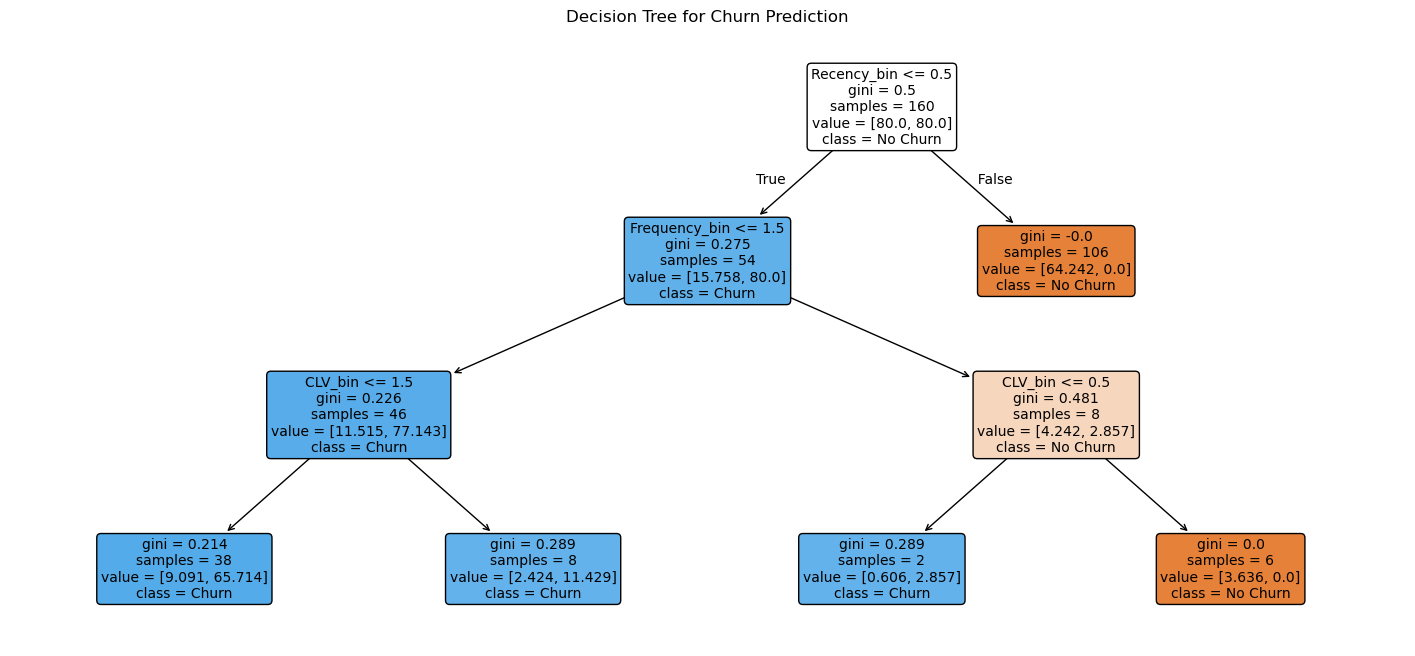

In [102]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt


df_model = rfm.copy()

df_model = df_model[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'CLV']].copy()

#Tạo nhãn churn

df_model['Churn'] = (df_model['Recency'] > 60).astype(int)

print("Phân bố Churn:")
print(df_model['Churn'].value_counts())
print("\nTỷ lệ Churn:")
print(df_model['Churn'].value_counts(normalize=True))

# Kiểm tra nếu chỉ có 1 lớp thì model sẽ không train đúng nghĩa
if df_model['Churn'].nunique() < 2:
    raise ValueError(
        "Cột Churn chỉ có 1 lớp. Hãy kiểm tra lại ngưỡng 60 ngày hoặc dữ liệu Recency."
    )

# 4. RỜI RẠC HÓA THÀNH 3 NHÓM
# Dùng qcut để chia theo quantile
# - Recency: càng nhỏ càng tốt, nên đảo nhãn
# - Frequency, Monetary, CLV: càng lớn càng tốt
# Nếu dữ liệu bị trùng nhiều và qcut lỗi, duplicates='drop' sẽ xử lý.
# =========================================================

def make_3_bins(series, labels, col_name):
    try:
        binned = pd.qcut(series, q=3, labels=labels, duplicates='drop')
        
        # Nếu do duplicates='drop' mà số bin bị giảm < 3 thì cần báo
        if pd.Series(binned).nunique() < 3:
            print(f"Cảnh báo: {col_name} không chia đủ 3 nhóm do nhiều giá trị trùng nhau.")
        
        return binned
    except Exception as e:
        raise ValueError(f"Lỗi khi chia bin cho cột {col_name}: {e}")

# Recency: 
# nhóm tốt nhất = 2, trung bình = 1, xấu nhất = 0
df_model['Recency_bin'] = make_3_bins(df_model['Recency'], labels=[2, 1, 0], col_name='Recency')

# Frequency: lớn tốt
df_model['Frequency_bin'] = make_3_bins(df_model['Frequency'], labels=[0, 1, 2], col_name='Frequency')

# Monetary: lớn tốt
df_model['Monetary_bin'] = make_3_bins(df_model['Monetary'], labels=[0, 1, 2], col_name='Monetary')

# CLV: lớn tốt
df_model['CLV_bin'] = make_3_bins(df_model['CLV'], labels=[0, 1, 2], col_name='CLV')

# Loại dòng NaN phát sinh sau binning nếu có
df_model = df_model.dropna(subset=['Recency_bin', 'Frequency_bin', 'Monetary_bin', 'CLV_bin']).copy()

# Chuyển sang int để train
for col in ['Recency_bin', 'Frequency_bin', 'Monetary_bin', 'CLV_bin']:
    df_model[col] = df_model[col].astype(int)

print("\nPreview dữ liệu train:")
print(df_model[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'CLV',
                'Recency_bin', 'Frequency_bin', 'Monetary_bin', 'CLV_bin', 'Churn']].head())

# 5. TẠO X, y

feature_cols = ['Recency_bin', 'Frequency_bin', 'Monetary_bin', 'CLV_bin']
X = df_model[feature_cols]
y = df_model['Churn']

# 6. TRAIN / TEST SPLIT
# stratify=y để giữ tỷ lệ churn giữa train/test


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nKích thước train/test:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

# 7. HUẤN LUYỆN DECISION TREE
# class_weight='balanced' hữu ích nếu churn lệch lớp


model = DecisionTreeClassifier(
    criterion='gini',        # hoặc 'entropy'
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# 8. DỰ ĐOÁN

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 9. ĐÁNH GIÁ MÔ HÌNH

print("\n" + "="*60)
print("KẾT QUẢ TRAIN")
print("="*60)
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, zero_division=0))
print("Recall   :", recall_score(y_train, y_train_pred, zero_division=0))
print("F1-score :", f1_score(y_train, y_train_pred, zero_division=0))
print("\nConfusion Matrix - Train:")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report - Train:")
print(classification_report(y_train, y_train_pred, zero_division=0))

print("\n" + "="*60)
print("KẾT QUẢ TEST")
print("="*60)
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_test_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_test_pred, zero_division=0))
print("\nConfusion Matrix - Test:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report - Test:")
print(classification_report(y_test, y_test_pred, zero_division=0))

# 10. FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# 11. IN LUẬT CÂY

tree_rules = export_text(model, feature_names=feature_cols)
print("\nLuật của cây quyết định:\n")
print(tree_rules)

# 12. VẼ CÂY

plt.figure(figsize=(18, 8))
plot_tree(
    model,
    feature_names=feature_cols,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Churn Prediction")
plt.show()

In [103]:
import pandas as pd

df = rfm.copy()

# 1. Tạo cột churn
df['Churn'] = (df['Recency'] > 60).map({True: 'Yes', False: 'No'})

# 2. Quy mô khách hàng
total_customers = df['CustomerID'].nunique()
churn_customers = df.loc[df['Churn'] == 'Yes', 'CustomerID'].nunique()
active_customers = df.loc[df['Churn'] == 'No', 'CustomerID'].nunique()

churn_rate = churn_customers / total_customers if total_customers else 0
active_rate = active_customers / total_customers if total_customers else 0

print("===== QUY MÔ KHÁCH HÀNG =====")
print(f"Tổng số khách hàng         : {total_customers}")
print(f"Số khách hàng rời bỏ       : {churn_customers}")
print(f"Số khách hàng còn hoạt động: {active_customers}")
print(f"Tỷ lệ churn                : {churn_rate:.2%}")
print(f"Tỷ lệ active               : {active_rate:.2%}")

# 3. Thống kê theo churn
summary_by_churn = df.groupby('Churn', as_index=False).agg(
    So_khach_hang=('CustomerID', 'nunique'),
    Tong_doanh_thu_lich_su=('Monetary', 'sum'),
    Doanh_thu_trung_binh_moi_khach=('Monetary', 'mean'),
    Tan_suat_mua_tb=('Frequency', 'mean'),
    CLV_trung_binh=('CLV', 'mean'),
    Tong_CLV=('CLV', 'sum')
)

print("\n===== THỐNG KÊ THEO NHÓM CHURN =====")
print(summary_by_churn)

# 4. Lấy trực tiếp từ summary
yes_row = summary_by_churn[summary_by_churn['Churn'] == 'Yes']

lost_revenue_historical = yes_row['Tong_doanh_thu_lich_su'].iloc[0] if not yes_row.empty else 0
lost_revenue_future_est = yes_row['Tong_CLV'].iloc[0] if not yes_row.empty else 0

total_revenue = df['Monetary'].sum()
revenue_loss_rate = lost_revenue_historical / total_revenue if total_revenue else 0

print("\n===== DOANH THU BỊ MẤT =====")
print(f"Tổng doanh thu lịch sử từ nhóm churn        : {lost_revenue_historical:,.0f}")
print(f"Ước tính giá trị tương lai bị mất (theo CLV): {lost_revenue_future_est:,.0f}")
print(f"Tổng doanh thu toàn bộ khách hàng           : {total_revenue:,.0f}")
print(f"Tỷ trọng doanh thu thuộc nhóm churn         : {revenue_loss_rate:.2%}")

# 5. Bảng tóm tắt
final_summary = pd.DataFrame({
    'Chi_tieu': [
        'Tong_so_khach_hang',
        'So_khach_hang_roi_bo',
        'Ty_le_churn',
        'So_khach_hang_con_hoat_dong',
        'Doanh_thu_lich_su_nhom_churn',
        'Tong_doanh_thu',
        'Ty_trong_doanh_thu_nhom_churn',
        'Gia_tri_tuong_lai_bi_mat_theo_CLV'
    ],
    'Gia_tri': [
        total_customers,
        churn_customers,
        round(churn_rate, 4),
        active_customers,
        round(lost_revenue_historical, 2),
        round(total_revenue, 2),
        round(revenue_loss_rate, 4),
        round(lost_revenue_future_est, 2)
    ]
})

print("\n===== BẢNG TÓM TẮT =====")
print(final_summary)

# 6. Danh sách khách churn giá trị cao
churn_customer_list = (
    df.loc[df['Churn'] == 'Yes', ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'CLV']]
      .sort_values(by=['CLV', 'Monetary'], ascending=False)
)

print("\n===== TOP KHÁCH HÀNG RỜI BỎ CÓ GIÁ TRỊ CAO =====")
print(churn_customer_list.head(10))

===== QUY MÔ KHÁCH HÀNG =====
Tổng số khách hàng         : 200
Số khách hàng rời bỏ       : 35
Số khách hàng còn hoạt động: 165
Tỷ lệ churn                : 17.50%
Tỷ lệ active               : 82.50%

===== THỐNG KÊ THEO NHÓM CHURN =====
  Churn  So_khach_hang  Tong_doanh_thu_lich_su  \
0    No            165            1.203323e+07   
1   Yes             35            2.268668e+06   

   Doanh_thu_trung_binh_moi_khach  Tan_suat_mua_tb  CLV_trung_binh  \
0                    72928.695488        25.454545    27348.260808   
1                    64819.096914        22.857143    24307.161343   

       Tong_CLV  
0  4.512463e+06  
1  8.507506e+05  

===== DOANH THU BỊ MẤT =====
Tổng doanh thu lịch sử từ nhóm churn        : 2,268,668
Ước tính giá trị tương lai bị mất (theo CLV): 850,751
Tổng doanh thu toàn bộ khách hàng           : 14,301,903
Tỷ trọng doanh thu thuộc nhóm churn         : 15.86%

===== BẢNG TÓM TẮT =====
                            Chi_tieu       Gia_tri
0                 T

kịch bản thay đổi churn

In [ ]:
df = rfm.copy()

# churn
df['Churn'] = (df['Recency'] > 60).astype(int)

total_customers = df.shape[0]
current_churn_rate = df['Churn'].mean()

print("Current churn rate:", round(current_churn_rate, 4))

Current churn rate: 0.175


Tính tổng CLV của nhóm churn

In [ ]:
churn_df = df[df['Churn'] == 1]

total_churn_clv = churn_df['CLV'].sum()
avg_clv_churn = churn_df['CLV'].mean()

print("Total CLV of churn group:", round(total_churn_clv, 2))
print("Avg CLV per churn customer:", round(avg_clv_churn, 2))

Total CLV of churn group: 850750.65
Avg CLV per churn customer: 24307.16


3. Xây dựng các kịch bản giảm churn

Ví dụ:

giảm 5%
giảm 10%
giảm 20%

In [ ]:
scenarios = [0.05, 0.10, 0.20]

results = []

for reduction in scenarios:
    
    # số khách giữ lại thêm
    saved_customers = int(total_customers * reduction)
    
    # doanh thu giữ lại (dựa trên CLV trung bình)
    saved_revenue = saved_customers * avg_clv_churn
    
    results.append({
        'Ty_le_giam_churn': f"{int(reduction*100)}%",
        'So_khach_giu_lai': saved_customers,
        'Doanh_thu_giu_lai_uoc_tinh': round(saved_revenue, 2)
    })

scenario_df = pd.DataFrame(results)

print("\n===== KỊCH BẢN GIẢM CHURN =====")
print(scenario_df)


===== KỊCH BẢN GIẢM CHURN =====
  Ty_le_giam_churn  So_khach_giu_lai  Doanh_thu_giu_lai_uoc_tinh
0               5%                10                   243071.61
1              10%                20                   486143.23
2              20%                40                   972286.45
